In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import pandas as pd

df = pd.read_csv("../data/Bengaluru_House_Data.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (13320, 9)


In [6]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  str    
 1   availability  13320 non-null  str    
 2   location      13319 non-null  str    
 3   size          13304 non-null  str    
 4   society       7818 non-null   str    
 5   total_sqft    13320 non-null  str    
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), str(6)
memory usage: 1.6 MB


In [8]:
df.isnull().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [9]:
# Fill missing location and size with the most common value
df['location'] = df['location'].fillna(df['location'].mode()[0])
df['size'] = df['size'].fillna(df['size'].mode()[0])

# Drop society because it has too many missing values
df = df.drop('society', axis=1)

# Fill missing numerical values with their median
df['bath'] = df['bath'].fillna(df['bath'].median())
df['balcony'] = df['balcony'].fillna(df['balcony'].median())

print("Missing values cleaned successfully!")

Missing values cleaned successfully!


In [10]:
df.isnull().sum()


area_type       0
availability    0
location        0
size            0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [11]:
df['total_sqft'].unique()[:20]

<ArrowStringArray>
['1056', '2600', '1440', '1521', '1200', '1170', '2732', '3300', '1310',
 '1020', '1800', '2785', '1000', '1100', '2250', '1175', '1180', '1540',
 '2770',  '600']
Length: 20, dtype: str

In [12]:
def convert_sqft_to_num(x):
    tokens = x.split('-')
    
    if len(tokens) == 1:
        try:
            return float(x)
        except:
            return None
    else:
        return (float(tokens[0]) + float(tokens[1])) / 2

df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)

print("total_sqft converted successfully!")
print(df['total_sqft'].dtype)

total_sqft converted successfully!
float64


In [13]:
df['bhk'] = df['size'].apply(lambda x: int(x.split(' ')[0]))

print("BHK column created successfully!")
print(df[['size', 'bhk']].head())

BHK column created successfully!
        size  bhk
0      2 BHK    2
1  4 Bedroom    4
2      3 BHK    3
3      3 BHK    3
4      2 BHK    2


In [14]:
df['bhk'].unique()

array([ 2,  4,  3,  6,  1,  8,  7,  5, 11,  9, 27, 10, 19, 16, 43, 14, 12,
       13, 18])

In [15]:
df[df['bhk'] > 10][['location', 'size', 'total_sqft', 'bhk', 'price']]

,location,size,total_sqft,bhk,price
459,1 Giri Nagar,11 BHK,5000.0,11,360.0
1718,2Electronic City Phase II,27 BHK,8000.0,27,230.0
1768,1 Ramamurthy Nagar,11 Bedroom,1200.0,11,170.0
3379,1Hanuman Nagar,19 BHK,2000.0,19,490.0
3609,Koramangala Industrial Layout,16 BHK,10000.0,16,550.0
3853,1 Annasandrapalya,11 Bedroom,1200.0,11,150.0
4684,Munnekollal,43 Bedroom,2400.0,43,660.0
4916,1Channasandra,14 BHK,1250.0,14,125.0
6533,Mysore Road,12 Bedroom,2232.0,12,300.0
7979,1 Immadihalli,11 BHK,6000.0,11,150.0


In [16]:
df = df[df['total_sqft'] / df['bhk'] >= 300]

print("Unrealistic BHK properties removed.")
print("New dataset shape:", df.shape)

Unrealistic BHK properties removed.
New dataset shape: (12530, 9)


In [17]:
df['price_per_sqft'] = (df['price'] * 100000) / df['total_sqft']

print("Price per square foot created successfully!")
print(df[['total_sqft', 'price', 'price_per_sqft']].head())

Price per square foot created successfully!
   total_sqft   price  price_per_sqft
0      1056.0   39.07     3699.810606
1      2600.0  120.00     4615.384615
2      1440.0   62.00     4305.555556
3      1521.0   95.00     6245.890861
4      1200.0   51.00     4250.000000


In [18]:
df['price_per_sqft'].describe()

count     12530.000000
mean       6303.979357
std        4162.237981
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [19]:
df = df[(df['price_per_sqft'] >= 1000) & (df['price_per_sqft'] <= 20000)]

print("Price outliers removed!")
print("New dataset shape:", df.shape)

Price outliers removed!
New dataset shape: (12362, 10)


In [20]:
print("Number of unique locations:", df['location'].nunique())
print("\nTop 20 locations:")
print(df['location'].value_counts().head(20))

Number of unique locations: 1197

Top 20 locations:
location
Whitefield                  536
Sarjapur  Road              395
Electronic City             292
Kanakpura Road              269
Thanisandra                 232
Yelahanka                   205
Uttarahalli                 180
Hebbal                      175
Marathahalli                170
Raja Rajeshwari Nagar       169
Hennur Road                 150
Bannerghatta Road           149
7th Phase JP Nagar          145
Haralur Road                140
Electronic City Phase II    126
Chandapura                   97
Rajaji Nagar                 96
Bellandur                    94
Electronics City Phase 1     87
KR Puram                     83
Name: count, dtype: int64


In [21]:
location_counts = df['location'].value_counts()

rare_locations = location_counts[location_counts <= 10].index

df['location'] = df['location'].apply(
    lambda x: 'other' if x in rare_locations else x
)

print("Locations after grouping rare locations:", df['location'].nunique())
print("\nTop locations:")
print(df['location'].value_counts().head(20))

Locations after grouping rare locations: 222

Top locations:
location
other                       2644
Whitefield                   536
Sarjapur  Road               395
Electronic City              292
Kanakpura Road               269
Thanisandra                  232
Yelahanka                    205
Uttarahalli                  180
Hebbal                       175
Marathahalli                 170
Raja Rajeshwari Nagar        169
Hennur Road                  150
Bannerghatta Road            149
7th Phase JP Nagar           145
Haralur Road                 140
Electronic City Phase II     126
Chandapura                    97
Rajaji Nagar                  96
Bellandur                     94
Electronics City Phase 1      87
Name: count, dtype: int64


In [22]:
df = df.drop(['area_type', 'availability', 'size', 'price_per_sqft'], axis=1)

print("Unnecessary columns removed!")
print("Remaining columns:")
print(df.columns.tolist())
print("\nDataset shape:", df.shape)

Unnecessary columns removed!
Remaining columns:
['location', 'total_sqft', 'bath', 'balcony', 'price', 'bhk']

Dataset shape: (12362, 6)


In [23]:
df = pd.get_dummies(df, columns=['location'], dtype=int)

print("Location converted to numerical columns!")
print("New dataset shape:", df.shape)

Location converted to numerical columns!
New dataset shape: (12362, 227)


In [24]:
X = df.drop('price', axis=1)
y = df['price']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (12362, 226)
y shape: (12362,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=10
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (9889, 226)
Testing data: (2473, 226)


In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [27]:
y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 5 predicted prices:")
print(y_pred[:5])

Predictions generated successfully!
First 5 predicted prices:
[ 66.13273845  88.67638478 140.48758117 209.37999678 186.00430474]


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Evaluation")
print("-----------------")
print("R² Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Model Evaluation
-----------------
R² Score: 0.7283635931462965
MAE: 29.510495698172967
RMSE: 51.165880867315984


In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=10,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [30]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated!")
print("First 5 predictions:")
print(rf_pred[:5])

Random Forest predictions generated!
First 5 predictions:
[ 71.02239722  83.67376667  64.86561429 168.16       152.2609    ]


In [31]:
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Evaluation")
print("------------------------")
print("R² Score:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest Evaluation
------------------------
R² Score: 0.67237059755732
MAE: 25.200090884361813
RMSE: 56.19244143530587


In [32]:
print("Actual price:     ", y_test.iloc[0])
print("Predicted price:  ", y_pred[0])
print("Difference:       ", abs(y_test.iloc[0] - y_pred[0]), "lakhs")

Actual price:      75.0
Predicted price:   66.13273844671394
Difference:        8.867261553286056 lakhs


In [44]:
print(type(model))
print(model)

<class 'sklearn.linear_model._base.LinearRegression'>
LinearRegression()


In [46]:
import pickle

model_path = "../model/house_price_model.pkl"

with open(model_path, "wb") as f:
    pickle.dump(model, f, protocol=4)

print("Model saved successfully!")
print("Saved to:", model_path)

Model saved successfully!
Saved to: ../model/house_price_model.pkl


In [34]:
def predict_price(location, total_sqft, bath, balcony, bhk):
    input_data = pd.DataFrame(
        columns=X.columns,
        data=np.zeros((1, len(X.columns)))
    )

    # Numerical features
    input_data['total_sqft'] = total_sqft
    input_data['bath'] = bath
    input_data['balcony'] = balcony
    input_data['bhk'] = bhk

    # Location
    location_column = 'location_' + location

    if location_column in input_data.columns:
        input_data[location_column] = 1
    elif 'location_other' in input_data.columns:
        input_data['location_other'] = 1
    else:
        print("Location not found. Using 'other'.")

    return model.predict(input_data)[0]

In [35]:
estimated_price = predict_price(
    'Whitefield',
    1200,
    2,
    1,
    2
)

print("Estimated house price:", round(estimated_price, 2), "lakhs")

Estimated house price: 69.92 lakhs


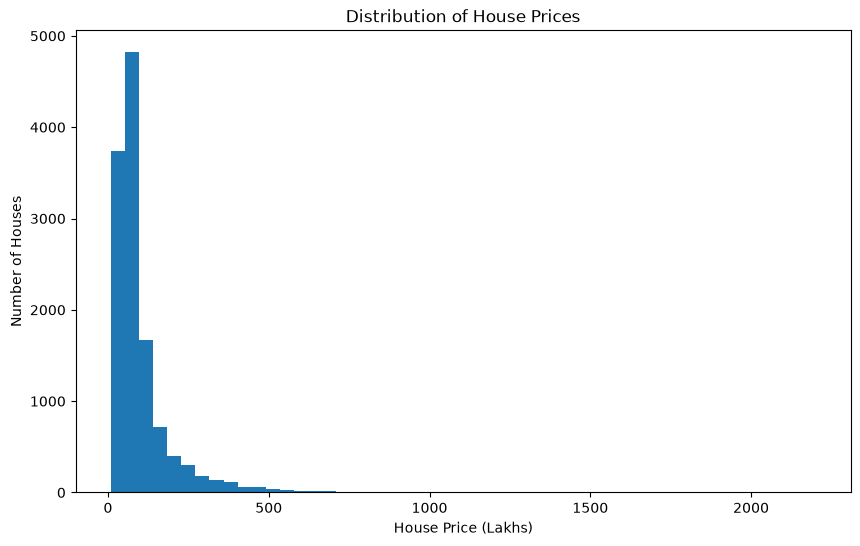

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['price'], bins=50)
plt.xlabel('House Price (Lakhs)')
plt.ylabel('Number of Houses')
plt.title('Distribution of House Prices')
plt.show()

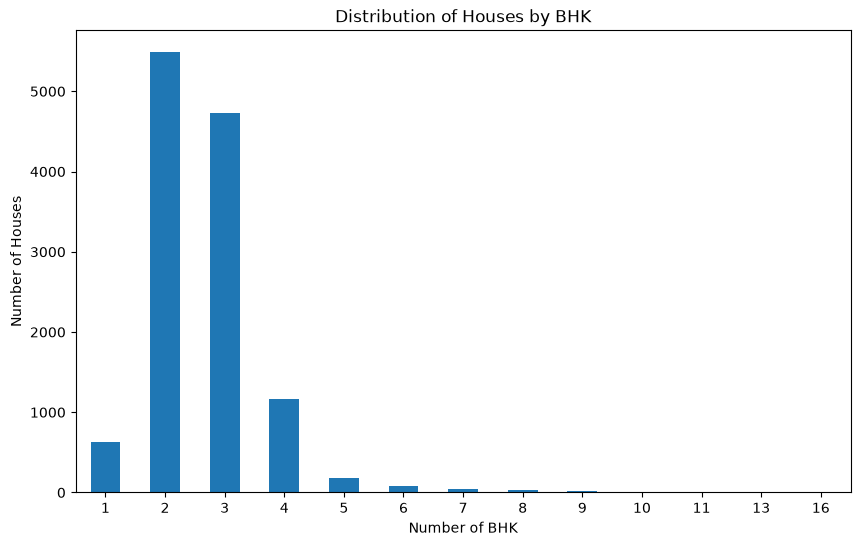

In [37]:
plt.figure(figsize=(10, 6))
df['bhk'].value_counts().sort_index().plot(kind='bar')
plt.xlabel('Number of BHK')
plt.ylabel('Number of Houses')
plt.title('Distribution of Houses by BHK')
plt.xticks(rotation=0)
plt.show()

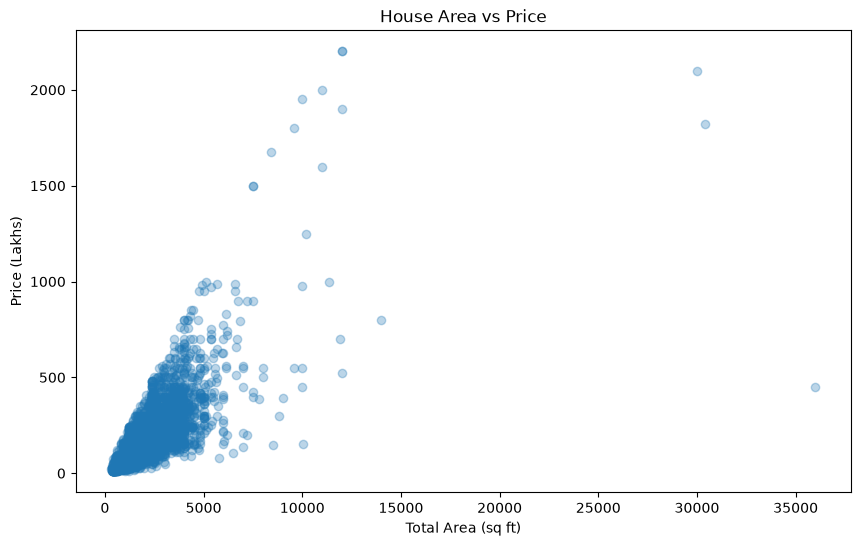

In [38]:
plt.figure(figsize=(10, 6))
plt.scatter(df['total_sqft'], df['price'], alpha=0.3)
plt.xlabel('Total Area (sq ft)')
plt.ylabel('Price (Lakhs)')
plt.title('House Area vs Price')
plt.show()

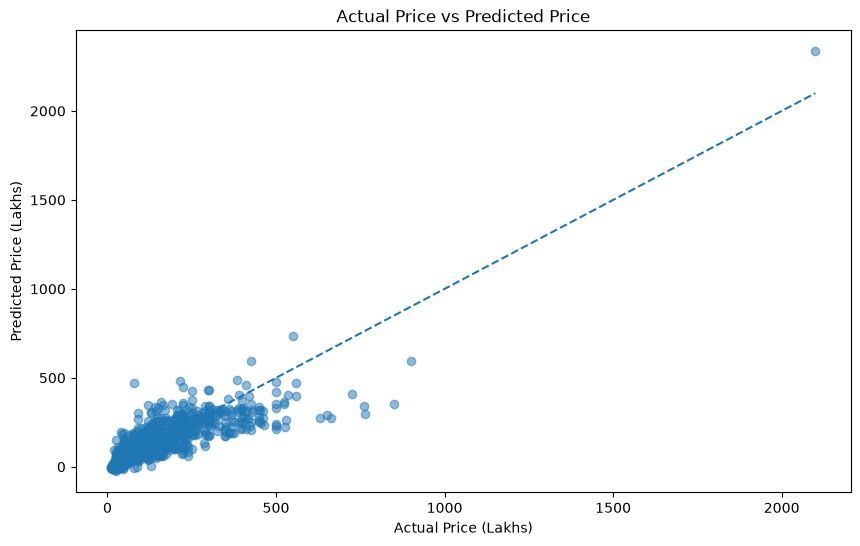

In [39]:
# Graph 4 — Actual Price vs Predicted Price

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual Price vs Predicted Price')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

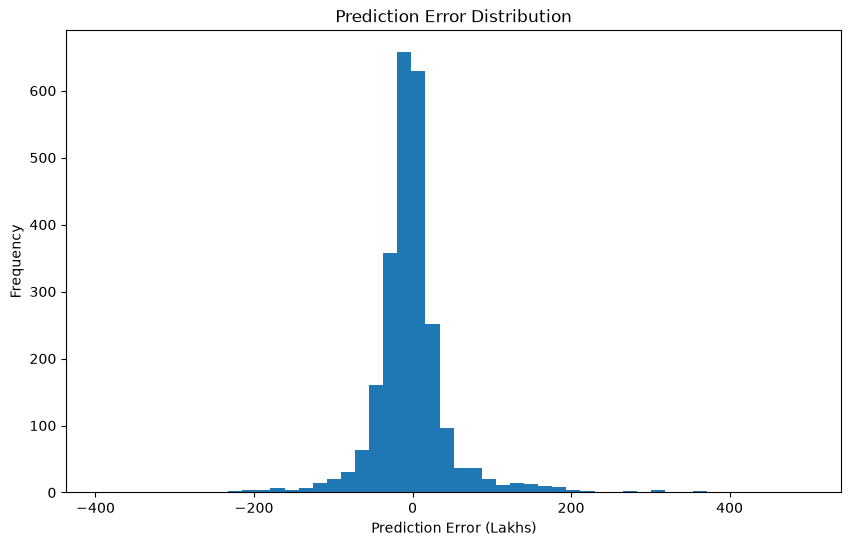

In [40]:
# Graph 5 — Prediction Error Distribution

errors = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.hist(errors, bins=50)

plt.xlabel('Prediction Error (Lakhs)')
plt.ylabel('Frequency')
plt.title('Prediction Error Distribution')

plt.show()

In [41]:
import joblib

joblib.dump(model, "../model/house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [42]:
import os

print("Model file exists:", os.path.exists("../model/house_price_model.pkl"))
print("Model folder contents:", os.listdir("../model"))

Model file exists: True
Model folder contents: ['house_price_model.pkl']


In [43]:
# Step 32 — Load the saved model and test prediction

import joblib

loaded_model = joblib.load("../model/house_price_model.pkl")

test_prediction = loaded_model.predict(X_test.iloc[[0]])

print("Saved model loaded successfully!")
print("Test prediction:", round(test_prediction[0], 2), "lakhs")
print("Actual price:", round(y_test.iloc[0], 2), "lakhs")

Saved model loaded successfully!
Test prediction: 66.13 lakhs
Actual price: 75.0 lakhs


# House Price Prediction — Project Summary

## Project Objective
The objective of this project is to predict house prices in Bengaluru using machine learning based on property-related features.

## Dataset
- Total records initially: 13,320
- Features initially: 9
- Dataset after preprocessing and outlier removal: 12,362 records
- Final features used for prediction:
  - Location
  - Total square feet
  - Bathroom
  - Balcony
  - BHK

## Data Preprocessing
The dataset was cleaned by:
- Handling missing values
- Converting total square feet into numerical values
- Extracting BHK from the size column
- Removing unrealistic BHK values
- Removing price-per-square-foot outliers
- Grouping rare locations into "other"
- Converting location into numerical features

## Machine Learning Models

### Linear Regression
- R² Score: 0.7284
- MAE: 29.51 lakhs
- RMSE: 51.17 lakhs

### Random Forest Regression
- R² Score: 0.6724
- MAE: 25.20 lakhs
- RMSE: 56.19 lakhs

Based on R² and RMSE, Linear Regression performed better overall for this dataset.

## Visualizations
The project includes:
1. House Price Distribution
2. BHK Distribution
3. House Area vs Price
4. Actual Price vs Predicted Price
5. Prediction Error Distribution

## Final Model
The trained Linear Regression model was saved as:

`house_price_model.pkl`

The saved model was successfully loaded and tested.

## Example Prediction
- Actual price: 75.00 lakhs
- Predicted price: 66.13 lakhs

The model successfully demonstrates the ability to estimate Bengaluru house prices from property features.